In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

2026-03-18 12:25:29.797968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773836729.956651      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773836730.003777      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773836730.375521      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773836730.375559      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773836730.375562      55 computation_placer.cc:177] computation placer alr

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32')
x_train = (x_train - 127.5) / 127.5  # Normalize to [-1, 1]

BUFFER_SIZE = 60000
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


I0000 00:00:1773836758.055219      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773836758.061112      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
latent_dim = 100

In [4]:
def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))

    model.add(layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh'))

    return model

generator = build_generator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[32,32,3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [7]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

In [8]:
EPOCHS = 20

for epoch in range(EPOCHS):
    for image_batch in dataset:
        train_step(image_batch)
    print(f"Epoch {epoch+1} completed")

E0000 00:00:1773836790.543893      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1_2/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1773836790.774674     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed


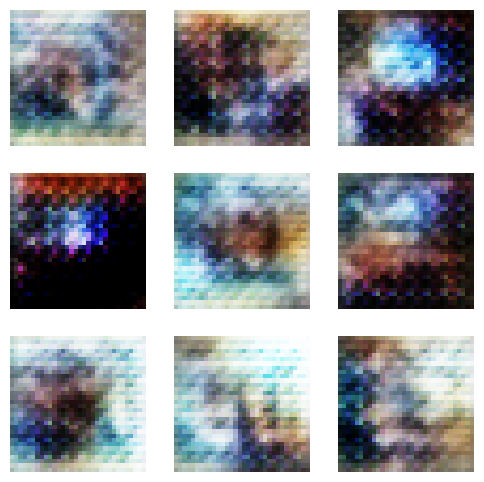

In [9]:
def generate_images(num_images=9):
    noise = tf.random.normal([num_images, latent_dim])
    generated_images = generator(noise, training=False)

    generated_images = (generated_images + 1) / 2

    plt.figure(figsize=(6,6))
    for i in range(num_images):
        plt.subplot(3,3,i+1)
        plt.imshow(generated_images[i])
        plt.axis('off')
    plt.show()

generate_images()

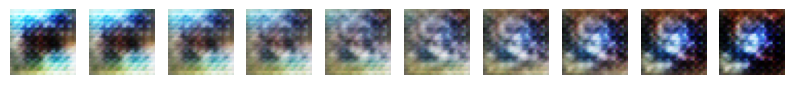

In [10]:
def interpolate(z1, z2, steps=10):
    z = [(1 - t) * z1 + t * z2 for t in np.linspace(0, 1, steps)]
    z = tf.stack(z)

    images = generator(z, training=False)
    images = (images + 1) / 2

    plt.figure(figsize=(10,2))
    for i in range(steps):
        plt.subplot(1, steps, i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.show()

z1 = tf.random.normal([latent_dim])
z2 = tf.random.normal([latent_dim])

interpolate(z1, z2)

In [11]:
generator.save("dcgan_generator.h5")

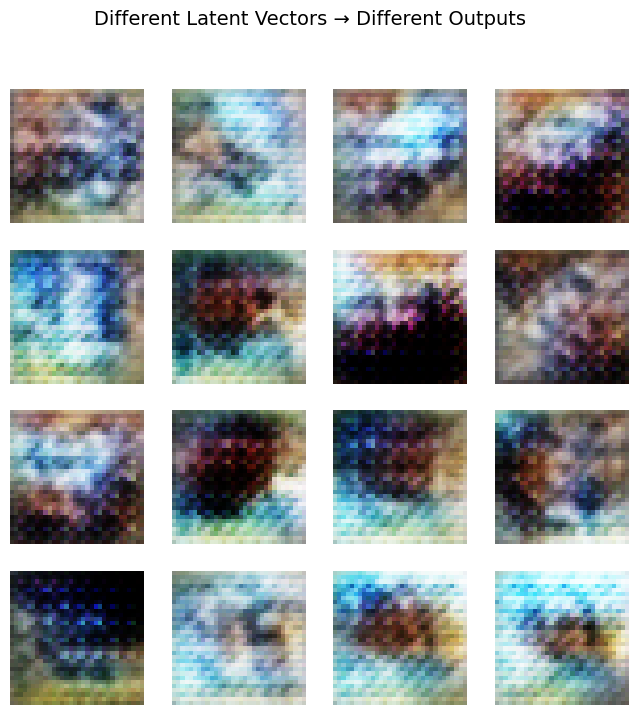

In [12]:
def visualize_latent_diversity():
    noise = tf.random.normal([16, latent_dim])
    images = generator(noise, training=False)
    images = (images + 1) / 2

    plt.figure(figsize=(8,8))
    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.suptitle("Different Latent Vectors → Different Outputs", fontsize=14)
    plt.show()

visualize_latent_diversity()

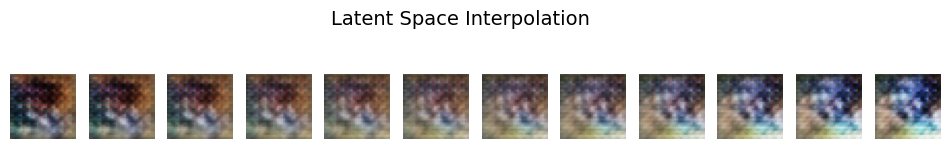

In [13]:
def smooth_interpolation():
    z1 = tf.random.normal([latent_dim])
    z2 = tf.random.normal([latent_dim])

    steps = 12
    interpolated = [(1-t)*z1 + t*z2 for t in np.linspace(0,1,steps)]
    interpolated = tf.stack(interpolated)

    images = generator(interpolated, training=False)
    images = (images + 1) / 2

    plt.figure(figsize=(12,2))
    for i in range(steps):
        plt.subplot(1, steps, i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.suptitle("Latent Space Interpolation", fontsize=14)
    plt.show()

smooth_interpolation()

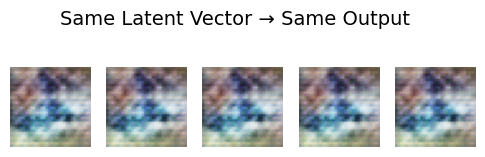

In [14]:
fixed_noise = tf.random.normal([1, latent_dim])

def test_stability():
    plt.figure(figsize=(6,2))
    for i in range(5):
        img = generator(fixed_noise, training=False)
        img = (img + 1) / 2
        plt.subplot(1,5,i+1)
        plt.imshow(img[0])
        plt.axis('off')
    plt.suptitle("Same Latent Vector → Same Output", fontsize=14)
    plt.show()

test_stability()

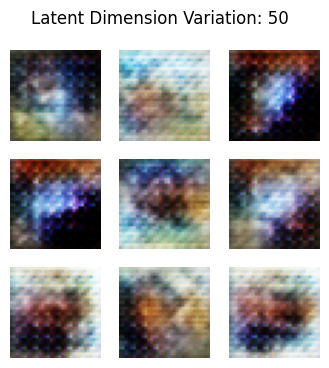

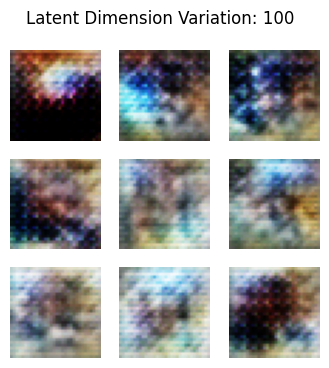

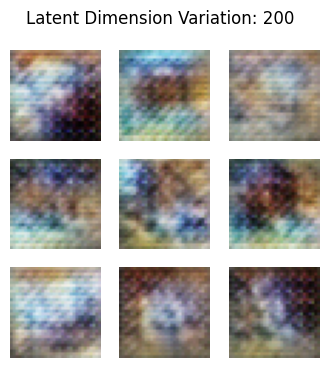

In [15]:
latent_dims = [50, 100, 200]

for dim in latent_dims:
    noise = tf.random.normal([9, dim])

    # resize noise if needed (simple trick)
    noise = tf.image.resize(tf.reshape(noise, (9, dim, 1, 1)), (latent_dim,1))
    noise = tf.reshape(noise, (9, latent_dim))

    images = generator(noise, training=False)
    images = (images + 1) / 2

    plt.figure(figsize=(4,4))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.suptitle(f"Latent Dimension Variation: {dim}", fontsize=12)
    plt.show()

In [17]:
num_classes = 10

def build_cgan_generator():
    noise = layers.Input(shape=(latent_dim,))
    label = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(num_classes, latent_dim)(label)
    label_embedding = layers.Flatten()(label_embedding)

    model_input = layers.multiply([noise, label_embedding])

    x = layers.Dense(8*8*256)(model_input)
    x = layers.Reshape((8,8,256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding='same')(x)
    x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh')(x)

    return tf.keras.Model([noise, label], x)

cgan_generator = build_cgan_generator()

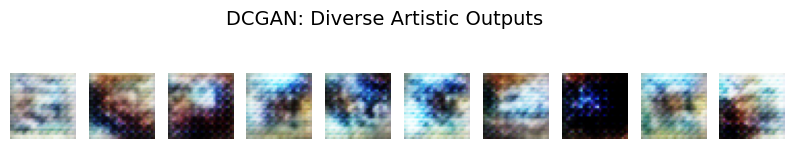

In [20]:
def generate_diverse_images():
    noise = tf.random.normal([10, latent_dim])
    images = generator(noise, training=False)
    images = (images + 1) / 2

    plt.figure(figsize=(10,2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.suptitle("DCGAN: Diverse Artistic Outputs", fontsize=14)
    plt.show()

generate_diverse_images()